In [1]:
import pandas as pd

t2012 = pd.read_csv("Tabela5-sem_emprego_2012.csv", sep=";")
t2026 = pd.read_csv("Tabela5-sem_emprego_2026.csv", sep=";")

comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")

path_t1 = "Tabela 1.1.1.xls"
bruto = pd.read_excel(path_t1, engine="xlrd", header=None)
indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)

geral = comp.merge(indicador_1, left_on="Estado", right_on="uf_regiao", how="inner")
geral.to_csv("geral.csv", sep=";", index=False, encoding="utf-8-sig")

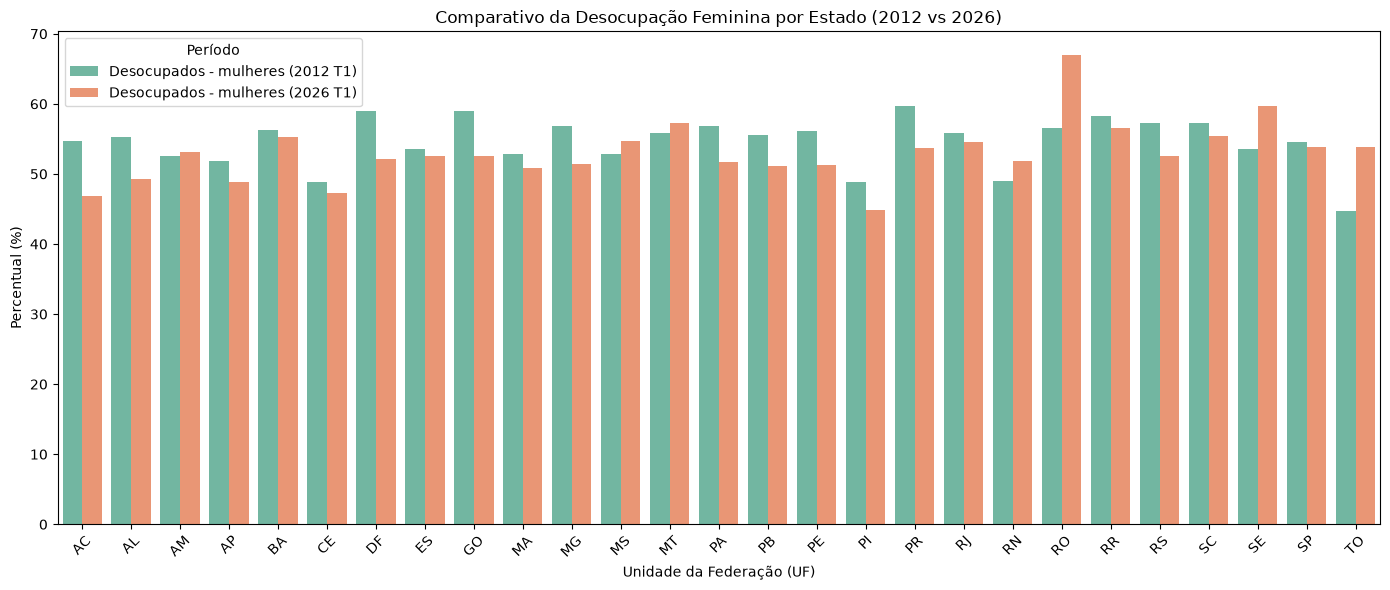

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

geral['Desocupados - mulheres (2012 T1)'] = geral['Desocupados - mulheres (2012 T1)'].astype(str).str.replace(',', '.').astype(float)
geral['Desocupados - mulheres (2026 T1)'] = geral['Desocupados - mulheres (2026 T1)'].astype(str).str.replace(',', '.').astype(float)

graf_df = geral[['Sigla', 'Desocupados - mulheres (2012 T1)', 'Desocupados - mulheres (2026 T1)']].melt(
    id_vars='Sigla', 
    var_name='Ano', 
    value_name='Percentual'
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=graf_df, x='Sigla', y='Percentual', hue='Ano', ax=ax, palette='Set2')
ax.set_title("Comparativo da Desocupação Feminina por Estado (2012 vs 2026)")
ax.set_xlabel("Unidade da Federação (UF)")
ax.set_ylabel("Percentual (%)")
plt.xticks(rotation=45)
plt.legend(title='Período')
plt.tight_layout()
plt.show()